# RLVR Run Dashboard

Use this after a smoke run or training run to inspect the learning signal. This is intentionally a notebook first: the views will evolve while we learn what matters.

Expected run command:

```bash
uv run python -m posttraining.rlvr.countdown_train max_steps=3
```

Then point `RUN_DIR` below at the run output directory.

In [1]:
from __future__ import annotations

import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

RUN_DIR = Path("../outputs/rlvr_countdown_qwen35_4b_smoke_tok512").resolve()
print(RUN_DIR)
print("exists:", RUN_DIR.exists())

/Users/dipakkrishnan/git/clones/posttraining/outputs/rlvr_countdown_qwen35_4b_smoke_tok512
exists: True


In [2]:
def read_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    records = []
    for line in path.read_text().splitlines():
        if line.strip():
            records.append(json.loads(line))
    return records


def metric_series(records: list[dict], key: str) -> tuple[list[int], list[float]]:
    xs, ys = [], []
    for row in records:
        if key in row and row[key] is not None:
            xs.append(int(row.get("step", len(xs))))
            ys.append(float(row[key]))
    return xs, ys


metrics = read_jsonl(RUN_DIR / "metrics.jsonl")
print("metrics rows:", len(metrics))
if metrics:
    print("sample keys:")
    print(sorted(metrics[-1].keys())[:80])
else:
    print("No metrics yet. Run a smoke experiment first.")

metrics rows: 3
sample keys:
['env/all/ac_tokens_per_turn', 'env/all/by_group/frac_all_bad', 'env/all/by_group/frac_all_good', 'env/all/by_group/frac_mixed', 'env/all/correct', 'env/all/format', 'env/all/ob_tokens_per_turn', 'env/all/reward/total', 'env/all/total_ac_tokens', 'env/all/total_episodes', 'env/all/total_ob_tokens', 'env/all/total_turns', 'env/all/turns_per_episode', 'optim/entropy', 'optim/kl_sample_train_v1', 'optim/kl_sample_train_v2', 'optim/lr', 'progress/batch', 'progress/done_frac', 'step', 'time/assemble_training_data', 'time/compute_full_batch_metrics_and_get_sampling_client', 'time/compute_group_rewards:count', 'time/compute_group_rewards:max', 'time/compute_group_rewards:mean', 'time/compute_group_rewards:total', 'time/compute_kl_sample_train', 'time/do_group_rollout_and_filter_constant_reward:count', 'time/do_group_rollout_and_filter_constant_reward:max', 'time/do_group_rollout_and_filter_constant_reward:mean', 'time/do_group_rollout_and_filter_constant_reward:to

## Scalar learning curves

These are the first curves to watch. Reward alone is not enough; separate format, correctness, entropy, and mixed-group rate.

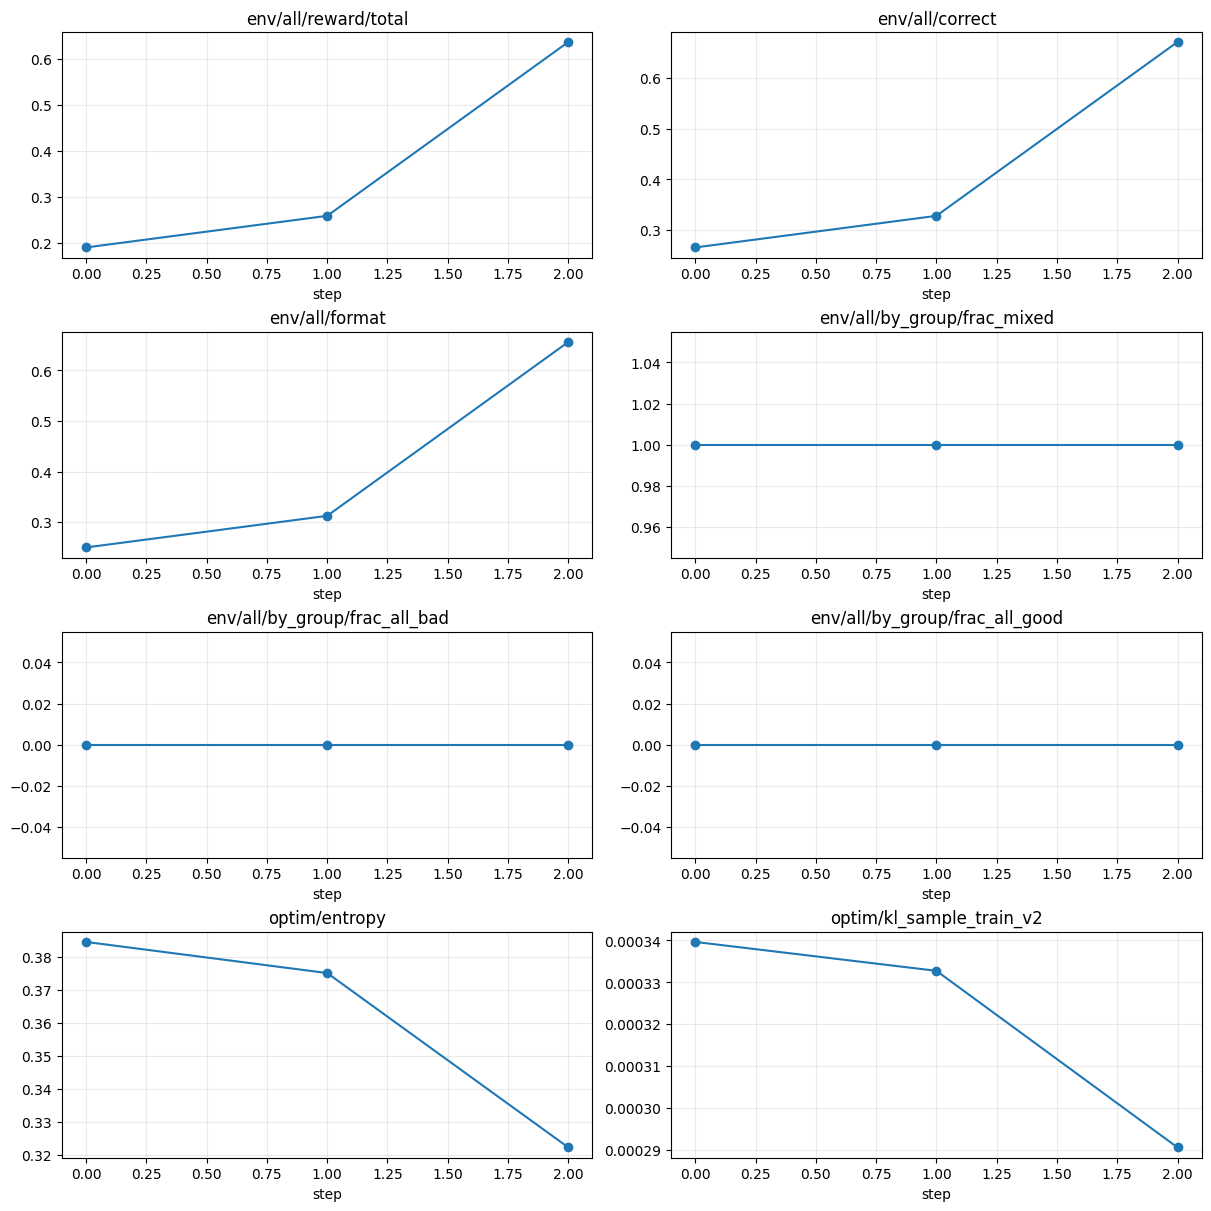

In [3]:
curve_keys = [
    "env/all/reward/total",
    "env/all/correct",
    "env/all/format",
    "env/all/by_group/frac_mixed",
    "env/all/by_group/frac_all_bad",
    "env/all/by_group/frac_all_good",
    "optim/entropy",
    "optim/kl_sample_train_v2",
]

fig, axes = plt.subplots(4, 2, figsize=(12, 12), constrained_layout=True)
for ax, key in zip(axes.ravel(), curve_keys, strict=False):
    xs, ys = metric_series(metrics, key)
    ax.plot(xs, ys, marker="o")
    ax.set_title(key)
    ax.set_xlabel("step")
    ax.grid(alpha=0.25)

for ax in axes.ravel()[len(curve_keys) :]:
    ax.axis("off")

plt.show()

## Rollout summaries

Rollout summaries are one JSON record per sampled trajectory. They are the best artifact for understanding why a step did or did not produce useful learning signal.

In [4]:
def rollout_paths(run_dir: Path, base_name: str = "train") -> list[Path]:
    return sorted(run_dir.glob(f"iteration_*/{base_name}_rollout_summaries.jsonl"))


paths = rollout_paths(RUN_DIR)
print("rollout files:", len(paths))
for path in paths[:5]:
    print(path.relative_to(RUN_DIR))

rollouts = []
for path in paths:
    rollouts.extend(read_jsonl(path))

print("rollout records:", len(rollouts))
if rollouts:
    print(rollouts[0].keys())

rollout files: 3
iteration_000000/train_rollout_summaries.jsonl
iteration_000001/train_rollout_summaries.jsonl
iteration_000002/train_rollout_summaries.jsonl
rollout records: 192
dict_keys(['schema_version', 'split', 'iteration', 'group_idx', 'traj_idx', 'tags', 'sampling_client_step', 'total_reward', 'final_reward', 'trajectory_metrics', 'steps', 'final_ob_len'])


In [5]:
def first_step_metrics(record: dict) -> dict:
    steps = record.get("steps") or []
    if not steps:
        return {}
    return steps[0].get("metrics") or {}


if rollouts:
    totals = [float(row["total_reward"]) for row in rollouts]
    print("reward histogram:", Counter(totals))
    for name in ["format", "correct"]:
        values = [first_step_metrics(row).get(name) for row in rollouts]
        print(name, Counter(values))
else:
    print("No rollout summaries yet.")

reward histogram: Counter({-0.1: 111, 1.0: 78, 0.9: 3})
format Counter({0.0: 114, 1.0: 78})
correct Counter({0.0: 111, 1.0: 81})


## Group signal view

For GRPO-style intuition, a useful group has reward variation. All-bad and all-good groups produce little centered-advantage signal.

In [6]:
groups = defaultdict(list)
for row in rollouts:
    groups[(row["iteration"], row["group_idx"])].append(row)

group_rows = []
for key, rows in groups.items():
    rewards = [float(row["total_reward"]) for row in rows]
    mean_reward = sum(rewards) / len(rewards)
    group_rows.append(
        {
            "iteration": key[0],
            "group_idx": key[1],
            "n": len(rows),
            "mean_reward": mean_reward,
            "min_reward": min(rewards),
            "max_reward": max(rewards),
            "mixed": min(rewards) != max(rewards),
        }
    )

print("groups:", len(group_rows))
print("mixed groups:", sum(row["mixed"] for row in group_rows))
group_rows[:10]

groups: 24
mixed groups: 24


[{'iteration': 0,
  'group_idx': 0,
  'n': 8,
  'mean_reward': 0.3125,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 1,
  'n': 8,
  'mean_reward': 0.43749999999999994,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 2,
  'n': 8,
  'mean_reward': 0.17499999999999993,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 3,
  'n': 8,
  'mean_reward': 0.175,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 4,
  'n': 8,
  'mean_reward': 0.037500000000000006,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 5,
  'n': 8,
  'mean_reward': 0.175,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'group_idx': 6,
  'n': 8,
  'mean_reward': 0.037500000000000006,
  'min_reward': -0.1,
  'max_reward': 1.0,
  'mixed': True},
 {'iteration': 0,
  'gro

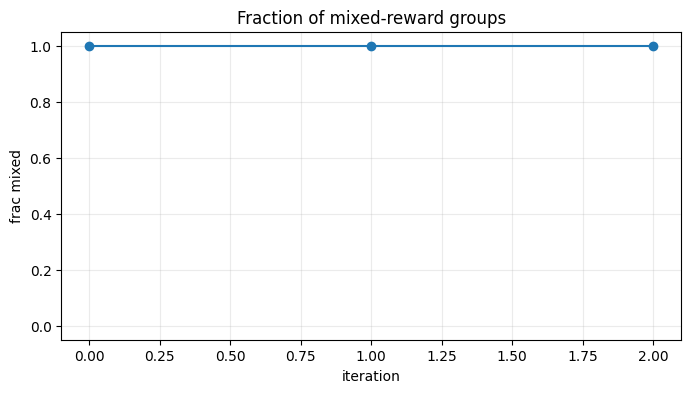

In [7]:
if group_rows:
    by_iteration = defaultdict(list)
    for row in group_rows:
        by_iteration[row["iteration"]].append(row)

    xs = sorted(by_iteration)
    ys = [sum(row["mixed"] for row in by_iteration[x]) / len(by_iteration[x]) for x in xs]

    plt.figure(figsize=(8, 4))
    plt.plot(xs, ys, marker="o")
    plt.title("Fraction of mixed-reward groups")
    plt.xlabel("iteration")
    plt.ylabel("frac mixed")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.25)
    plt.show()

## Advantage intuition for one group

Advantages are centered rewards within a group: `advantage = reward - group_mean_reward`.

In [8]:
mixed_key = None
for key, rows in groups.items():
    rewards = [float(row["total_reward"]) for row in rows]
    if min(rewards) != max(rewards):
        mixed_key = key
        break

if mixed_key is None:
    print("No mixed group found yet. Try more steps or larger group_size.")
else:
    rows = groups[mixed_key]
    rewards = [float(row["total_reward"]) for row in rows]
    mean_reward = sum(rewards) / len(rewards)
    print("iteration/group:", mixed_key)
    print("mean reward:", round(mean_reward, 3))
    for row in rows:
        reward = float(row["total_reward"])
        advantage = reward - mean_reward
        metrics = first_step_metrics(row)
        print(
            {
                "traj": row["traj_idx"],
                "reward": reward,
                "advantage": round(advantage, 3),
                "format": metrics.get("format"),
                "correct": metrics.get("correct"),
                "ac_len": (row.get("steps") or [{}])[0].get("ac_len"),
            }
        )

iteration/group: (0, 0)
mean reward: 0.312
{'traj': 0, 'reward': -0.1, 'advantage': -0.412, 'format': 0.0, 'correct': 0.0, 'ac_len': 512}
{'traj': 1, 'reward': 1.0, 'advantage': 0.688, 'format': 1.0, 'correct': 1.0, 'ac_len': 217}
{'traj': 2, 'reward': -0.1, 'advantage': -0.412, 'format': 0.0, 'correct': 0.0, 'ac_len': 512}
{'traj': 3, 'reward': 1.0, 'advantage': 0.688, 'format': 1.0, 'correct': 1.0, 'ac_len': 214}
{'traj': 4, 'reward': -0.1, 'advantage': -0.412, 'format': 0.0, 'correct': 0.0, 'ac_len': 512}
{'traj': 5, 'reward': 1.0, 'advantage': 0.688, 'format': 1.0, 'correct': 1.0, 'ac_len': 234}
{'traj': 6, 'reward': -0.1, 'advantage': -0.412, 'format': 0.0, 'correct': 0.0, 'ac_len': 512}
{'traj': 7, 'reward': -0.1, 'advantage': -0.412, 'format': 0.0, 'correct': 0.0, 'ac_len': 512}


## Where to inspect full text

The rollout summaries intentionally stay compact. For full prompt/response text, open the logtree HTML/JSON files in the iteration directories.

In [9]:
logtrees = sorted(RUN_DIR.glob("iteration_*/*_logtree.json"))
htmls = sorted(RUN_DIR.glob("iteration_*/*.html"))

print("logtree json files:", len(logtrees))
for path in logtrees[:10]:
    print(path.relative_to(RUN_DIR))

print("\nhtml files:", len(htmls))
for path in htmls[:10]:
    print(path.relative_to(RUN_DIR))

logtree json files: 3
iteration_000000/train_logtree.json
iteration_000001/train_logtree.json
iteration_000002/train_logtree.json

html files: 3
iteration_000000/train.html
iteration_000001/train.html
iteration_000002/train.html
